# Redundancy Analysis Tutorial

This notebook demonstrates the `pepbenchmark.redundancy` module for analyzing dataset redundancy and quality.

**Learning Objectives:**
1. Basic redundancy metrics computation
2. Multi-threshold redundancy assessment
3. Interpreting quality recommendations
4. Visualizing redundancy trends

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pepbenchmark.redundancy import RedundancyAnalyzer, RedundancyReport

# For visualization
plt.style.use('seaborn-v0_8-darkgrid')
print("Setup complete!")

/home/batchcom/assist/miniforge3/envs/pepbenchmark/lib/python3.10/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Setup complete!


## Example 1: Basic Redundancy Analysis

Compute redundancy metrics on a small peptide sequence set.

In [2]:
# Create sample sequences
sequences = [
    "ACDEFGHIKLMNPQRSTVWY",  # Full alphabet (0)
    "ACDEFGHIKLMNPQRSTVWY",  # Exact duplicate of (0)
    "ACDEFGHIKLMNPQRSTV",    # Slightly different (1)
    "MVHLTSQPAK",             # Unrelated (2)
    "MVHLTSQPAK",             # Exact duplicate of (3)
    "KSRADITPGW",             # Unrelated (4)
]

# Create similarity matrix (e.g., from Levenshtein or sequence alignment)
# For simplicity, using a mock matrix
sim_matrix = np.array([
    [1.00, 0.95, 0.90, 0.15, 0.12, 0.18],  # seq 0
    [0.95, 1.00, 0.88, 0.14, 0.95, 0.16],  # seq 1 (similar to 0, 4)
    [0.90, 0.88, 1.00, 0.10, 0.12, 0.15],  # seq 2
    [0.15, 0.14, 0.10, 1.00, 0.92, 0.20],  # seq 3
    [0.12, 0.95, 0.12, 0.92, 1.00, 0.18],  # seq 4 (similar to 1, 3)
    [0.18, 0.16, 0.15, 0.20, 0.18, 1.00],  # seq 5
])

print(f"✓ Created {len(sequences)} sequences")
print(f"✓ Similarity matrix shape: {sim_matrix.shape}")
print()
print("Sequence summary:")
for i, seq in enumerate(sequences):
    print(f"  [{i}] {seq} (length={len(seq)})")

✓ Created 6 sequences
✓ Similarity matrix shape: (6, 6)

Sequence summary:
  [0] ACDEFGHIKLMNPQRSTVWY (length=20)
  [1] ACDEFGHIKLMNPQRSTVWY (length=20)
  [2] ACDEFGHIKLMNPQRSTV (length=18)
  [3] MVHLTSQPAK (length=10)
  [4] MVHLTSQPAK (length=10)
  [5] KSRADITPGW (length=10)


In [3]:
# Initialize analyzer
analyzer = RedundancyAnalyzer(sequences, sim_matrix)
print("✓ RedundancyAnalyzer initialized")

# Compute metrics
report = analyzer.compute_metrics(
    thresholds=(0.7, 0.8, 0.9),
    topk=3,
    compute_kmer=True,
    compute_graph=True
)
print("✓ Metrics computed")

✓ RedundancyAnalyzer initialized
✓ Metrics computed


### Basic Statistics

In [4]:
# Display basic statistics
basic = report.basic
print(f"Basic Statistics:")
print(f"  Total sequences: {basic.n_total}")
print(f"  Unique sequences: {basic.n_unique}")
print(f"  Exact duplicates: {basic.n_total - basic.n_unique}")
print(f"  Duplication rate: {basic.exact_duplicate_rate:.1%}")

Basic Statistics:
  Total sequences: 6
  Unique sequences: 4
  Exact duplicates: 2
  Duplication rate: 33.3%


### Length Distribution

In [5]:
length = report.length
print(f"Length Statistics:")
print(f"  Mean: {length.mean_len:.1f}")
print(f"  Std: {length.std_len:.1f}")
print(f"  Range: {length.min_len}-{length.max_len} (CV={length.len_cv:.2f})")

Length Statistics:
  Mean: 14.7
  Std: 4.7
  Range: 10-20 (CV=0.32)


### Amino Acid Composition

In [6]:
aa = report.aa
print(f"Amino Acid Statistics:")
print(f"  Entropy: {aa.aa_entropy:.2f}")
print(f"  Most frequent AA: {aa.most_freq_aa} ({aa.most_freq_aa_freq:.1%})")
print(f"  Unique residues: {aa.unique_residues}")
print(f"  KL-divergence from uniform: {aa.aa_kl_to_uniform:.2f}")

Amino Acid Statistics:
  Entropy: 2.95
  Most frequent AA: A (6.8%)
  Unique residues: 20
  KL-divergence from uniform: 0.04


### Similarity Statistics

In [7]:
sim = report.similarity
print(f"Similarity Statistics (pairwise):")
print(f"  Mean: {sim.pair_mean:.3f}")
print(f"  Median: {sim.pair_median:.3f}")
print(f"  Std: {sim.pair_std:.3f}")
print(f"  Range: {sim.pair_min:.3f}-{sim.pair_max:.3f}")

topk = report.topk
print(f"\nTop-K Statistics (k=3):")
print(f"  Mean top-k similarity: {topk.topk_mean_sim:.3f}")
print(f"  Median top-k similarity: {topk.topk_median:.3f}")

Similarity Statistics (pairwise):
  Mean: 0.407
  Median: 0.180
  Std: 0.364
  Range: 0.100-0.950

Top-K Statistics (k=3):
  Mean top-k similarity: 0.590
  Median top-k similarity: 0.880


## Example 2: Multi-Threshold Redundancy Assessment

Analyze redundancy at different similarity thresholds (0.7, 0.8, 0.9).

In [8]:
# Extract redundancy metrics
redundancy = report.redundancy

# Create summary table
threshold_data = []
for thr in sorted(redundancy.redundancy_rates.keys()):
    threshold_data.append({
        'Threshold': f"{thr:.1f}",
        'Redundancy Rate': f"{redundancy.redundancy_rates[thr]:.1%}",
        'Neff': f"{redundancy.neff[thr]:.2f}",
    })

df_thresholds = pd.DataFrame(threshold_data)
print("Redundancy Analysis by Threshold:")
print(df_thresholds.to_string(index=False))
print()
print("Interpretation:")
print("  - Redundancy Rate: % of sequence pairs above threshold (0=diverse, 1=redundant)")
print("  - Neff: Effective sequence count accounting for similarity clustering")

Redundancy Analysis by Threshold:
Threshold Redundancy Rate Neff
      0.7           33.3% 2.75
      0.8           33.3% 2.75
      0.9           26.7% 3.00

Interpretation:
  - Redundancy Rate: % of sequence pairs above threshold (0=diverse, 1=redundant)
  - Neff: Effective sequence count accounting for similarity clustering


In [9]:
# Detailed breakdown
print("Detailed Results:")
for thr in sorted(redundancy.redundancy_rates.keys()):
    rate = redundancy.redundancy_rates[thr]
    neff = redundancy.neff[thr]
    print(f"\n  Threshold = {thr}:")
    print(f"    - {rate:.1%} of pairs are redundant (similarity ≥ {thr})")
    print(f"    - Neff = {neff:.2f} (effective diversity)")
    print(f"    - Information loss: {(1 - neff/len(sequences))*100:.1f}%")

Detailed Results:

  Threshold = 0.7:
    - 33.3% of pairs are redundant (similarity ≥ 0.7)
    - Neff = 2.75 (effective diversity)
    - Information loss: 54.2%

  Threshold = 0.8:
    - 33.3% of pairs are redundant (similarity ≥ 0.8)
    - Neff = 2.75 (effective diversity)
    - Information loss: 54.2%

  Threshold = 0.9:
    - 26.7% of pairs are redundant (similarity ≥ 0.9)
    - Neff = 3.00 (effective diversity)
    - Information loss: 50.0%


## Example 3: Visualization

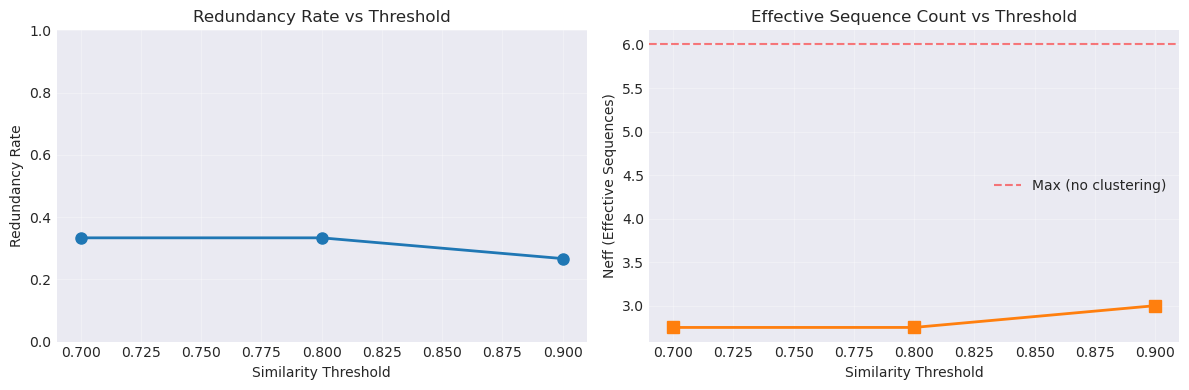

✓ Plots generated


In [10]:
# Plot redundancy trends
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Redundancy Rate vs Threshold
thresholds = sorted(redundancy.redundancy_rates.keys())
rates = [redundancy.redundancy_rates[t] for t in thresholds]
axes[0].plot(thresholds, rates, 'o-', linewidth=2, markersize=8, color='#1f77b4')
axes[0].set_xlabel('Similarity Threshold')
axes[0].set_ylabel('Redundancy Rate')
axes[0].set_title('Redundancy Rate vs Threshold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot 2: Neff vs Threshold
neffs = [redundancy.neff[t] for t in thresholds]
axes[1].plot(thresholds, neffs, 's-', linewidth=2, markersize=8, color='#ff7f0e')
axes[1].axhline(y=len(sequences), color='red', linestyle='--', alpha=0.5, label='Max (no clustering)')
axes[1].set_xlabel('Similarity Threshold')
axes[1].set_ylabel('Neff (Effective Sequences)')
axes[1].set_title('Effective Sequence Count vs Threshold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("✓ Plots generated")

## Example 4: Quality Assessment and Recommendations

In [11]:
rec = report.recommendation
print("Quality Assessment:")
print(f"  Quality Score: {rec.data_quality_score:.1%}")
print(f"  Redundancy Severity: {rec.redundancy_severity.upper()}")
print(f"  Recommended Threshold: {rec.recommended_threshold}")
print()
print("Interpretation:")

if rec.data_quality_score > 0.9:
    print("  ✓ Excellent quality - low exact duplication")
elif rec.data_quality_score > 0.7:
    print("  ⚠ Good quality - some exact duplication")
else:
    print("  ✗ Poor quality - high exact duplication")

if rec.redundancy_severity == "low":
    print("  ✓ Low redundancy - dataset is diverse")
elif rec.redundancy_severity == "medium":
    print("  ⚠ Medium redundancy - consider filtering")
else:
    print("  ✗ High redundancy - strongly recommend filtering")

print(f"\n  Action: Use threshold ≥ {rec.recommended_threshold} for filtering")

Quality Assessment:
  Quality Score: 66.7%
  Redundancy Severity: MEDIUM
  Recommended Threshold: 0.9

Interpretation:
  ✗ Poor quality - high exact duplication
  ⚠ Medium redundancy - consider filtering

  Action: Use threshold ≥ 0.9 for filtering


## Example 5: Neff Analysis

Understanding effective sequence count and diversity loss.

In [12]:
# Calculate diversity loss at each threshold
print("Diversity Loss Analysis:")
print()
for thr in sorted(redundancy.neff.keys()):
    neff = redundancy.neff[thr]
    loss = (1 - neff / len(sequences)) * 100
    clusters = len(sequences) / neff if neff > 0 else 0
    print(f"  Threshold {thr}:")
    print(f"    - Neff: {neff:.2f}/{len(sequences)} sequences")
    print(f"    - Information loss: {loss:.1f}%")
    print(f"    - Avg cluster size: {clusters:.2f}")
    print()

Diversity Loss Analysis:

  Threshold 0.7:
    - Neff: 2.75/6 sequences
    - Information loss: 54.2%
    - Avg cluster size: 2.18

  Threshold 0.8:
    - Neff: 2.75/6 sequences
    - Information loss: 54.2%
    - Avg cluster size: 2.18

  Threshold 0.9:
    - Neff: 3.00/6 sequences
    - Information loss: 50.0%
    - Avg cluster size: 2.00



## Summary

Key takeaways from the tutorial:

1. **RedundancyAnalyzer** provides one-stop analysis for dataset quality
2. **Multi-threshold approach** helps select appropriate filtering thresholds
3. **Neff metric** captures effective diversity accounting for clustering
4. **Recommendations** automate threshold and severity assessment
5. **Visualization** makes redundancy trends intuitive

For more details, see the module documentation in `README.md`.